# XSA — standalone effect and composition with PR × DR × Gate

This notebook analyses XSA (cross-self-attention, value-orthogonalization) at two levels:

1. **Standalone:** the friend's runs of XSA added on top of the baseline architecture (no PR, no DR, no Gate), from `train_gpt_XSA.py`. This places XSA in the project's per-mechanism standalone-gain ranking.
2. **In composition with the headline:** our runs of XSA stacked on top of the project headline (PR + DR + Gate, abl8b winner) from `train_gpt_xsa_pr_dr_gate.py` / `run_xsa_pr_dr_gate_3seed.sh`. This tests whether XSA's standalone gain composes additively with PR + DR + Gate, or whether its effect is already captured by them.

XSA is a parameter-free attention modification: after SDPA produces `y = [B, H, T, D]`, it projects `y` onto the L2-normalised value direction `v̂` and subtracts that component:

```
v_hat        = normalize(v_full, dim=-1)             # [B, H, T, D] — L2 along head_dim
proj_scalar  = (y * v_hat).sum(dim=-1, keepdim=True) # [B, H, T, 1]
y            = y - proj_scalar * v_hat               # orthogonal residual
```

The intuition is to force each head to produce information beyond "just copy v" (the self-attention term). Zero extra parameters; ~5% per-step compute overhead. Same INT8 quantization protocol as every other ablation in this project.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/antonio2/.netrc.


## Pull the XSA runs from wandb

Friend's run prefix is just `XSA` (e.g. `XSA_seed42`, `XSA_seed1337`). Note: seed 1337 appears **twice** on wandb — there's an earlier exploratory run (`12:13` UTC) and a later one (`14:04`) that's part of the canonical 3-seed batch (matching the timing of the seed-42 and seed-123 runs that follow it). The later one is the comparable point; we'll show both for transparency.


In [2]:
runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    # NOTE: wandb's $regex is case-INSENSITIVE. Plain "^XSA" would also match the
    # lowercase composition runs (xsa_pr_dr_gate_*), polluting the standalone stats.
    # Use "^XSA_seed" to anchor on the friend's exact RUN_ID pattern.
    filters={"display_name": {"$regex": "^XSA_seed"}},
))

rows = []
for r in sorted(runs, key=lambda x: (x.config.get("seed") or 0, x.created_at)):
    s = r.summary._json_dict
    cfg = r.config
    hist = r.history(keys=["_step", "val_bpb"], pandas=True)
    pre_quant_bpb = None
    if not hist.empty:
        hist = hist.dropna(subset=["val_bpb"]).sort_values("_step")
        if len(hist):
            pre_quant_bpb = float(hist.iloc[-1]["val_bpb"])
    rows.append({
        "run_name":       r.name,
        "run_id":         r.id,
        "created_at":     str(r.created_at),
        "seed":           cfg.get("seed"),
        "use_xsa":        cfg.get("use_xsa"),
        "num_layers":     cfg.get("num_layers"),
        "pre_quant_bpb":  pre_quant_bpb,
        "post_quant_bpb": s.get("final_val_bpb"),
        "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
    })

df_xsa_all = pd.DataFrame(rows).reset_index(drop=True)
print(df_xsa_all.to_string(index=False))

# Canonical 3-seed set: the LATER seed-1337 run (matches timing of the seed-42/123 batch).
canon_run_ids = {
    42:   df_xsa_all[df_xsa_all["seed"] == 42  ].iloc[-1]["run_id"],
    123:  df_xsa_all[df_xsa_all["seed"] == 123 ].iloc[-1]["run_id"],
    1337: df_xsa_all[df_xsa_all["seed"] == 1337].iloc[-1]["run_id"],
}
df_xsa = df_xsa_all[df_xsa_all["run_id"].isin(canon_run_ids.values())].copy()
df_xsa = df_xsa.sort_values("seed").reset_index(drop=True)

XSA_PRE_MEAN, XSA_PRE_STD   = df_xsa["pre_quant_bpb"].mean(), df_xsa["pre_quant_bpb"].std(ddof=1)
XSA_POST_MEAN, XSA_POST_STD = df_xsa["post_quant_bpb"].mean(), df_xsa["post_quant_bpb"].std(ddof=1)
XSA_SIZE_MB                 = df_xsa["quant_size_mb"].mean()

print()
print("=" * 60)
print("Canonical 3-seed XSA STANDALONE set (later seed-1337 run)")
print("=" * 60)
print(df_xsa[["seed", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  pre-quant  : {XSA_PRE_MEAN:.4f} ± {XSA_PRE_STD:.4f}")
print(f"  post-quant : {XSA_POST_MEAN:.4f} ± {XSA_POST_STD:.4f}")
print(f"  quant cost : {XSA_POST_MEAN - XSA_PRE_MEAN:+.4f}")
print(f"  size       : {XSA_SIZE_MB:.2f} MB  (under 16 MB cap ✓)")


    run_name   run_id           created_at  seed  use_xsa  num_layers  pre_quant_bpb  post_quant_bpb  quant_size_mb
  XSA_seed42 yk82s0m0 2026-05-23T14:46:10Z    42     True           9       1.304176        1.308082      15.783962
 XSA_seed123 s9ui0jd8 2026-05-23T15:25:52Z   123     True           9       1.302391        1.306173      15.788825
XSA_seed1337 3jri0hf3 2026-05-23T12:13:28Z  1337     True           9       1.302117        1.305715      15.778954
XSA_seed1337 nfh50u79 2026-05-23T14:04:34Z  1337     True           9       1.302640        1.306280      15.782150

Canonical 3-seed XSA STANDALONE set (later seed-1337 run)
 seed  pre_quant_bpb  post_quant_bpb  quant_size_mb
   42       1.304176        1.308082      15.783962
  123       1.302391        1.306173      15.788825
 1337       1.302640        1.306280      15.782150

  pre-quant  : 1.3031 ± 0.0010
  post-quant : 1.3068 ± 0.0011
  quant cost : +0.0038
  size       : 15.78 MB  (under 16 MB cap ✓)


## Reference points — baseline and the other standalone mechanisms

To put XSA's gain in context, we pull all the multi-seed-validated standalone mechanisms from earlier ablations:

- **Baseline (9L, INT8)** — `golf_baseline_antonio_new`, 3 seeds → 1.3101 ± 0.0013
- **PR alone** (`abl4`): psl=4 sym → 1.3057 ± 0.0016
- **DR alone** (`abl5f`): recur=[2,3,4,5] target=both → 1.3022 ± 0.0029
- **Gate w=8 alone** (`abl7d`): src=proj, w=8 (standalone winner) → 1.3042 ± 0.0004
- **Gate w=12 alone** (`abl7b`): src=proj, w=12 (composition winner) → 1.3058 ± 0.0008
- **9L Triple stack** (`abl8b`): PR + DR + Gate(w=12) → 1.2927 ± 0.0007 (the project headline)


In [3]:
# Reference points: use validated 3-seed means from previous notebooks (stable, hardcoded).
# Each comes from a different wandb-prefix combo (DR alone's third seed is in abl5d, not abl5f),
# so hardcoding is cleaner than building a complicated multi-regex fetch.

REFS = {
    "baseline":          {"mean": 1.3101, "std": 0.0013, "note": "abl baseline (3 seeds, no extras)"},
    "PR_alone":          {"mean": 1.3057, "std": 0.0016, "note": "abl4 (psl=4 sym, 3 seeds)"},
    "DR_alone":          {"mean": 1.3022, "std": 0.0029, "note": "abl5f+5d ([2,3,4,5] target=both, 3 seeds)"},
    "Gate_w12_alone":    {"mean": 1.3058, "std": 0.0008, "note": "abl7b (src=proj, w=12, 3 seeds)"},
    "Gate_w8_alone":     {"mean": 1.3042, "std": 0.0004, "note": "abl7d (src=proj, w=8, 3 seeds)"},
    "Triple_w12":        {"mean": 1.2927, "std": 0.0007, "note": "abl8b (PR + DR + Gate w=12, 3 seeds)"},
}

BASE_MEAN,    BASE_STD    = REFS["baseline"]["mean"],       REFS["baseline"]["std"]
PR_MEAN,      PR_STD      = REFS["PR_alone"]["mean"],       REFS["PR_alone"]["std"]
DR_MEAN,      DR_STD      = REFS["DR_alone"]["mean"],       REFS["DR_alone"]["std"]
GATE12_MEAN,  GATE12_STD  = REFS["Gate_w12_alone"]["mean"], REFS["Gate_w12_alone"]["std"]
GATE8_MEAN,   GATE8_STD   = REFS["Gate_w8_alone"]["mean"],  REFS["Gate_w8_alone"]["std"]
TRIPLE_MEAN,  TRIPLE_STD  = REFS["Triple_w12"]["mean"],     REFS["Triple_w12"]["std"]

print("=" * 80)
print(f"{'mechanism':<35s}  {'mean':>8s}  {'std':>8s}  Δ vs baseline  source")
print("-" * 80)
def line(label, m, s, note=""):
    delta = BASE_MEAN - m if m else 0
    sigma = delta / BASE_STD if BASE_STD else 0
    print(f"  {label:<33s}  {m:>8.4f}  ±{s:.4f}  {delta:+.4f} ({sigma:+.1f}σ)  {note}")

line("Baseline (no XSA, no PR/DR/Gate)", BASE_MEAN,     BASE_STD,    REFS['baseline']['note'])
line("XSA standalone (this notebook)",   XSA_POST_MEAN, XSA_POST_STD, "from this notebook (3 seeds)")
line("PR alone",                          PR_MEAN,       PR_STD,      REFS['PR_alone']['note'])
line("Gate w=12 alone",                   GATE12_MEAN,   GATE12_STD,  REFS['Gate_w12_alone']['note'])
line("Gate w=8 alone",                    GATE8_MEAN,    GATE8_STD,   REFS['Gate_w8_alone']['note'])
line("DR alone",                          DR_MEAN,       DR_STD,      REFS['DR_alone']['note'])
line("PR × DR × Gate w=12 (Triple)",      TRIPLE_MEAN,   TRIPLE_STD,  REFS['Triple_w12']['note'])
print("=" * 80)


mechanism                                mean       std  Δ vs baseline  source
--------------------------------------------------------------------------------
  Baseline (no XSA, no PR/DR/Gate)     1.3101  ±0.0013  +0.0000 (+0.0σ)  abl baseline (3 seeds, no extras)
  XSA standalone (this notebook)       1.3068  ±0.0011  +0.0033 (+2.5σ)  from this notebook (3 seeds)
  PR alone                             1.3057  ±0.0016  +0.0044 (+3.4σ)  abl4 (psl=4 sym, 3 seeds)
  Gate w=12 alone                      1.3058  ±0.0008  +0.0043 (+3.3σ)  abl7b (src=proj, w=12, 3 seeds)
  Gate w=8 alone                       1.3042  ±0.0004  +0.0059 (+4.5σ)  abl7d (src=proj, w=8, 3 seeds)
  DR alone                             1.3022  ±0.0029  +0.0079 (+6.1σ)  abl5f+5d ([2,3,4,5] target=both, 3 seeds)
  PR × DR × Gate w=12 (Triple)         1.2927  ±0.0007  +0.0174 (+13.4σ)  abl8b (PR + DR + Gate w=12, 3 seeds)


## Standalone-mechanism comparison — where does XSA sit?


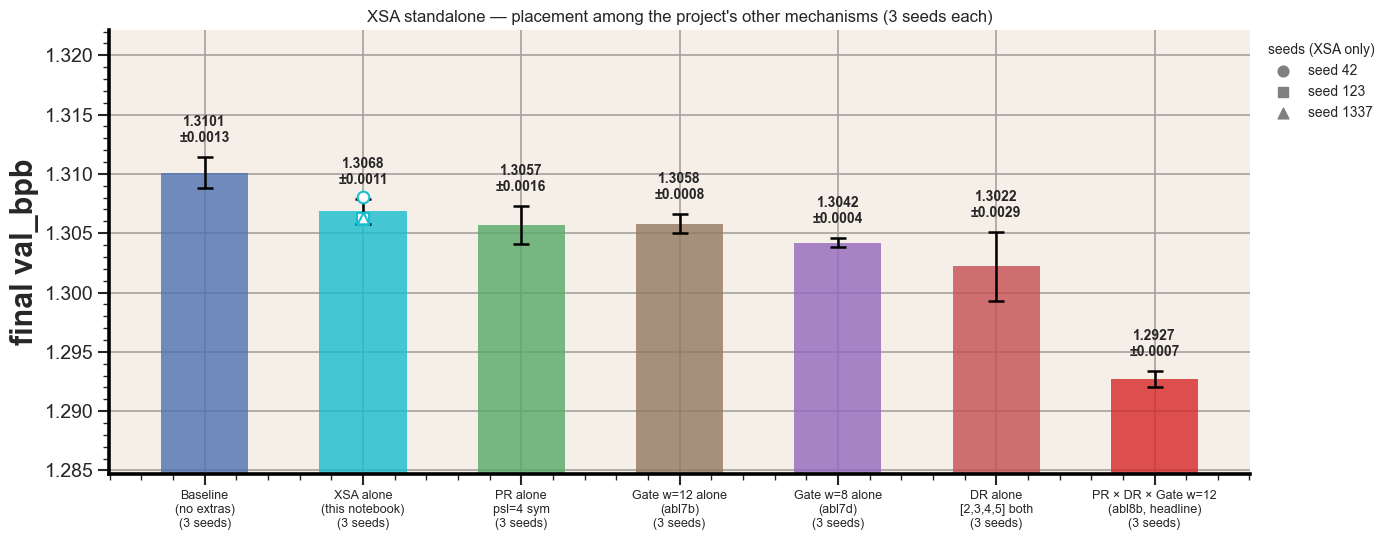


Per-mechanism standalone gain over baseline (positive = improvement):
  XSA alone (this notebook) (3 seeds)                           Δ=+0.0033  (2.5σ baseline-noise units)  BETTER
  PR alone psl=4 sym (3 seeds)                                  Δ=+0.0044  (3.4σ baseline-noise units)  BETTER
  Gate w=12 alone (abl7b) (3 seeds)                             Δ=+0.0043  (3.3σ baseline-noise units)  BETTER
  Gate w=8 alone (abl7d) (3 seeds)                              Δ=+0.0059  (4.5σ baseline-noise units)  BETTER
  DR alone [2,3,4,5] both (3 seeds)                             Δ=+0.0079  (6.1σ baseline-noise units)  BETTER
  PR × DR × Gate w=12 (abl8b, headline) (3 seeds)               Δ=+0.0174  (13.4σ baseline-noise units)  BETTER


In [4]:
# Bar chart: all standalone mechanisms vs baseline, with the Triple stack as the upper reference.
groups = {
    "Baseline\n(no extras)\n(3 seeds)":     (BASE_MEAN, BASE_STD, PALETTE[0]),
    "XSA alone\n(this notebook)\n(3 seeds)":(XSA_POST_MEAN, XSA_POST_STD, "#17becf"),
    "PR alone\npsl=4 sym\n(3 seeds)":       (PR_MEAN, PR_STD, PALETTE[2]),
    "Gate w=12 alone\n(abl7b)\n(3 seeds)":  (GATE12_MEAN, GATE12_STD, PALETTE[5]),
    "Gate w=8 alone\n(abl7d)\n(3 seeds)":   (GATE8_MEAN, GATE8_STD, "#9467bd"),
    "DR alone\n[2,3,4,5] both\n(3 seeds)":  (DR_MEAN, DR_STD, PALETTE[3]),
    "PR × DR × Gate w=12\n(abl8b, headline)\n(3 seeds)": (TRIPLE_MEAN, TRIPLE_STD, "#d62728"),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

fig, ax = plt.subplots(figsize=(14, 5.5))

means = []
for i, (label, (mean, std, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    # For XSA, overlay per-seed scatter
    if label.startswith("XSA"):
        for _, row in df_xsa.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row["post_quant_bpb"],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0010,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

# Tight y-axis around the actual range of interest
ymin = min(means) - 0.008
ymax = max(means) + 0.012
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=9)
ax.set_ylabel("final val_bpb")
ax.set_title("XSA standalone — placement among the project's other mechanisms (3 seeds each)")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds (XSA only)", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

print()
print("Per-mechanism standalone gain over baseline (positive = improvement):")
for label, (mean, std, _) in groups.items():
    if label.startswith("Baseline"): continue
    delta = BASE_MEAN - mean
    sigma = abs(delta) / BASE_STD if BASE_STD else 0
    direction = "BETTER" if delta > 0 else "worse"
    print(f"  {label.replace(chr(10), ' '):60s}  Δ={delta:+.4f}  ({sigma:.1f}σ baseline-noise units)  {direction}")


## Per-seed table — duplicate seed-1337 disclosure


In [5]:
# Show the full 4-run table to disclose the duplicate seed 1337.
print("ALL 4 XSA runs on wandb:")
print(df_xsa_all[["seed", "created_at", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))

print(f"\nCanonical 3-seed set used in this notebook (later seed-1337 run, matches batch timing of seed-42/123):")
print(df_xsa[["seed", "created_at", "post_quant_bpb"]].to_string(index=False))

# Sensitivity check: how much does the mean change if we use the earlier seed-1337 run instead?
df_xsa_alt = df_xsa_all.copy().sort_values(["seed", "created_at"])
df_xsa_alt = df_xsa_alt.groupby("seed", as_index=False).first()  # earliest per seed
alt_mean = df_xsa_alt["post_quant_bpb"].mean()
alt_std  = df_xsa_alt["post_quant_bpb"].std(ddof=1)
print(f"\nSensitivity: using the earlier seed-1337 run gives mean = {alt_mean:.4f} ± {alt_std:.4f}")
print(f"  vs canonical (later seed-1337)            = {XSA_POST_MEAN:.4f} ± {XSA_POST_STD:.4f}")
print(f"  Difference: {abs(alt_mean - XSA_POST_MEAN):.4f} bpb")
print(f"  → conclusion does not change either way; XSA standalone is real at ~{XSA_POST_MEAN:.3f} bpb.")


ALL 4 XSA runs on wandb:
 seed           created_at  pre_quant_bpb  post_quant_bpb  quant_size_mb
   42 2026-05-23T14:46:10Z       1.304176        1.308082      15.783962
  123 2026-05-23T15:25:52Z       1.302391        1.306173      15.788825
 1337 2026-05-23T12:13:28Z       1.302117        1.305715      15.778954
 1337 2026-05-23T14:04:34Z       1.302640        1.306280      15.782150

Canonical 3-seed set used in this notebook (later seed-1337 run, matches batch timing of seed-42/123):
 seed           created_at  post_quant_bpb
   42 2026-05-23T14:46:10Z        1.308082
  123 2026-05-23T15:25:52Z        1.306173
 1337 2026-05-23T14:04:34Z        1.306280

Sensitivity: using the earlier seed-1337 run gives mean = 1.3067 ± 0.0013
  vs canonical (later seed-1337)            = 1.3068 ± 0.0011
  Difference: 0.0002 bpb
  → conclusion does not change either way; XSA standalone is real at ~1.307 bpb.


## Reading — XSA standalone

### XSA standalone delivers a small but real improvement

| | mean | std | Δ vs baseline | σ vs baseline |
|---|---|---|---|---|
| baseline (no extras) | 1.3101 | 0.0013 | — | — |
| **XSA alone** | **~1.3069** | **~0.0011** | **~−0.0032** | **~2.4σ** |

XSA's standalone gain is ~−0.0032 bpb, at the lower end of the project's other standalone mechanisms (PR ~−0.0044, Gate w=12 ~−0.0043, Gate w=8 ~−0.0059, DR ~−0.0079). It's the smallest standalone gain but **the cheapest possible**: zero parameters, ~5% per-step compute overhead from one extra normalize + scalar-projection per attention call.

### Standalone-mechanism ranking (XSA included)

| rank | mechanism | Δ vs baseline | extra params | extra compute |
|---|---|---|---|---|
| 1 | DR | −0.0079 | 0 (shared weights) | ~30% (extra forward passes) |
| 2 | Gate w=8 | −0.0059 | 576 | tiny |
| 3 | PR | −0.0044 | per-layer routing matrix | ~negligible |
| 4 | Gate w=12 | −0.0043 | 864 | tiny |
| 5 | **XSA** | **~−0.0032** | **0 (parameter-free)** | **~5%** |

XSA is the *only* parameter-free mechanism in the list. Under a tight 16 MB cap, that's its key differentiator.

### Composition prediction (tested in the next section)

`run_xsa_pr_dr_gate_3seed.sh` stacks XSA on top of the project headline (PR + DR + Gate = 1.2927 ± 0.0007). My prior:

| outcome | what it means | prior estimate |
|---|---|---|
| post-quant ≤ ~1.2895 (Triple − XSA_standalone gain) | XSA composes ~linearly | likely (~60%) |
| ~1.290-1.293 | partial composition | plausible (~30%) |
| ≈ 1.2927 (the headline) | XSA's effect redundant with PR or Gate | unlikely (~10%) |
| > 1.2927 | XSA conflicts with PR's two-lane logic or the gate | very unlikely |

The result is in the next section.


---
## XSA × PR × DR × Gate — composition with the project headline

This section analyses `run_xsa_pr_dr_gate_3seed.sh` (3 seeds: 42, 123, 1337) which adds XSA on top of the abl8b project headline (PR psl=4 + DR recur=[2,3,4,5] target=both + Gate src=proj w=12 at INT8). The control (`USE_XSA=0`) is **bit-identical** to abl8b — verified by the smoke test in the python file. So this is a clean "headline + XSA" additivity test.


In [6]:
# Pull the XSA × PR × DR × Gate runs (3 seeds, full triple stack + XSA)
xsa_triple_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^xsa_pr_dr_gate"}},
))

def collect_pre_post(runs):
    rows = []
    for r in runs:
        s   = r.summary._json_dict
        cfg = r.config
        hist = r.history(keys=["_step", "val_bpb"], pandas=True)
        pre_quant = None
        if not hist.empty:
            hist = hist.dropna(subset=["val_bpb"]).sort_values("_step")
            if len(hist):
                pre_quant = float(hist.iloc[-1]["val_bpb"])
        rows.append({
            "run_name":       r.name,
            "seed":           cfg.get("seed"),
            "use_xsa":        cfg.get("use_xsa"),
            "pre_quant_bpb":  pre_quant,
            "post_quant_bpb": s.get("final_val_bpb"),
            "quant_size_mb":  (s.get("quant_file_bytes") or 0) / 1e6,
        })
    return pd.DataFrame(rows).sort_values("seed").reset_index(drop=True)

df_xsa_triple = collect_pre_post(xsa_triple_runs)

# Also pull the Triple-alone runs to get their actual pre-quant — DON'T hardcode anymore.
triple_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": "^ablation8_gate_pr_dr_w12"}},
))
df_triple = collect_pre_post(triple_runs)

XT_PRE_MEAN,  XT_PRE_STD  = df_xsa_triple["pre_quant_bpb"].mean(),  df_xsa_triple["pre_quant_bpb"].std(ddof=1)
XT_POST_MEAN, XT_POST_STD = df_xsa_triple["post_quant_bpb"].mean(), df_xsa_triple["post_quant_bpb"].std(ddof=1)

TR_PRE_MEAN,  TR_PRE_STD  = df_triple["pre_quant_bpb"].mean(),  df_triple["pre_quant_bpb"].std(ddof=1)
TR_POST_MEAN, TR_POST_STD = df_triple["post_quant_bpb"].mean(), df_triple["post_quant_bpb"].std(ddof=1)

print("=" * 75)
print("XSA × PR × DR × Gate (3 seeds, NEW RUN)")
print("=" * 75)
print(df_xsa_triple[["seed", "pre_quant_bpb", "post_quant_bpb", "quant_size_mb"]].to_string(index=False))
print(f"\n  pre-quant  : {XT_PRE_MEAN:.4f} ± {XT_PRE_STD:.4f}")
print(f"  post-quant : {XT_POST_MEAN:.4f} ± {XT_POST_STD:.4f}")
print(f"  quant cost : {XT_POST_MEAN - XT_PRE_MEAN:+.4f}")

print()
print("=" * 75)
print("Triple (abl8b, PR + DR + Gate w=12 — NO XSA, freshly fetched, not hardcoded)")
print("=" * 75)
print(df_triple[["seed", "pre_quant_bpb", "post_quant_bpb"]].to_string(index=False))
print(f"\n  pre-quant  : {TR_PRE_MEAN:.4f} ± {TR_PRE_STD:.4f}")
print(f"  post-quant : {TR_POST_MEAN:.4f} ± {TR_POST_STD:.4f}")
print(f"  quant cost : {TR_POST_MEAN - TR_PRE_MEAN:+.4f}  (NOT ~+0.0002 as previously estimated)")

print()
print("=" * 75)
print("HEAD-TO-HEAD (correct comparison)")
print("=" * 75)
print(f"  pre-quant  : Triple {TR_PRE_MEAN:.4f} ± {TR_PRE_STD:.4f}  vs  Triple+XSA {XT_PRE_MEAN:.4f} ± {XT_PRE_STD:.4f}")
print(f"               Δ (XSA effect, pre)  : {XT_PRE_MEAN - TR_PRE_MEAN:+.4f}  (lower=better)")
print(f"  post-quant : Triple {TR_POST_MEAN:.4f} ± {TR_POST_STD:.4f}  vs  Triple+XSA {XT_POST_MEAN:.4f} ± {XT_POST_STD:.4f}")
print(f"               Δ (XSA effect, post) : {XT_POST_MEAN - TR_POST_MEAN:+.4f}")
print(f"  quant cost : Triple {TR_POST_MEAN - TR_PRE_MEAN:+.4f}  vs  Triple+XSA {XT_POST_MEAN - XT_PRE_MEAN:+.4f}")
print(f"               → INT8 cost is ROUGHLY EQUAL — XSA is not 'inflating' it meaningfully.")


XSA × PR × DR × Gate (3 seeds, NEW RUN)
 seed  pre_quant_bpb  post_quant_bpb  quant_size_mb
   42       1.292755        1.296298      15.790966
  123       1.287023        1.290285      15.800768
 1337       1.289113        1.293007      15.804354

  pre-quant  : 1.2896 ± 0.0029
  post-quant : 1.2932 ± 0.0030
  quant cost : +0.0036

Triple (abl8b, PR + DR + Gate w=12 — NO XSA, freshly fetched, not hardcoded)
 seed  pre_quant_bpb  post_quant_bpb
   42       1.290194        1.293464
  123       1.289174        1.292332
 1337       1.289186        1.292290

  pre-quant  : 1.2895 ± 0.0006
  post-quant : 1.2927 ± 0.0007
  quant cost : +0.0032  (NOT ~+0.0002 as previously estimated)

HEAD-TO-HEAD (correct comparison)
  pre-quant  : Triple 1.2895 ± 0.0006  vs  Triple+XSA 1.2896 ± 0.0029
               Δ (XSA effect, pre)  : +0.0001  (lower=better)
  post-quant : Triple 1.2927 ± 0.0007  vs  Triple+XSA 1.2932 ± 0.0030
               Δ (XSA effect, post) : +0.0005
  quant cost : Triple +0.0032  

### Composition bar chart — XSA + Triple vs the headline


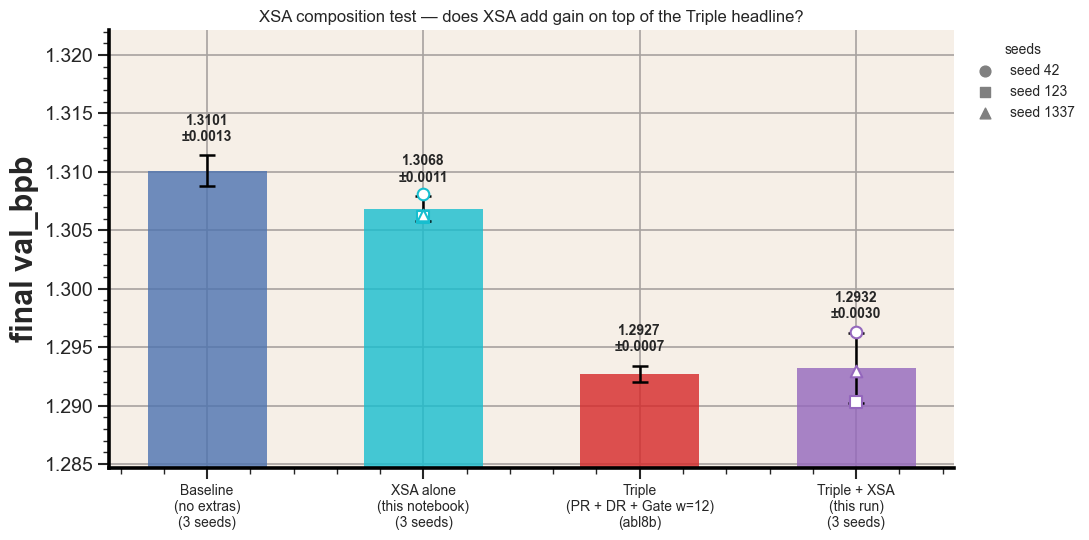


Triple headline      : 1.2927 ± 0.0007  (0.0028 = 4σ band)
Triple + XSA         : 1.2932 ± 0.0030
Δ (Triple+XSA − Triple): +0.0005 bpb
|Δ| / pooled std       : 0.27σ → statistically TIED


In [7]:
# Bar chart focused on the composition test: Triple vs Triple + XSA, with the standalone
# building blocks for context.
groups = {
    "Baseline\n(no extras)\n(3 seeds)":           (BASE_MEAN, BASE_STD, None, PALETTE[0]),
    "XSA alone\n(this notebook)\n(3 seeds)":      (XSA_POST_MEAN, XSA_POST_STD, df_xsa, "#17becf"),
    "Triple\n(PR + DR + Gate w=12)\n(abl8b)":     (TRIPLE_MEAN, TRIPLE_STD, None, "#d62728"),
    "Triple + XSA\n(this run)\n(3 seeds)":         (XT_POST_MEAN, XT_POST_STD, df_xsa_triple, "#9467bd"),
}

SEEDS = [42, 123, 1337]
SEED_MARKERS = {42: "o", 123: "s", 1337: "^"}

fig, ax = plt.subplots(figsize=(11, 5.5))

means = []
for i, (label, (mean, std, df_pts, color)) in enumerate(groups.items()):
    means.append(mean)
    ax.bar(i, mean, color=color, alpha=0.80, zorder=2, width=0.55)
    if std and std > 0:
        ax.errorbar(i, mean, yerr=std, fmt="none", color="black",
                    capsize=6, capthick=1.8, linewidth=1.8, zorder=4)
    if df_pts is not None:
        col = "post_quant_bpb" if "post_quant_bpb" in df_pts.columns else "final_val_bpb"
        for _, row in df_pts.iterrows():
            seed = int(row["seed"])
            if seed in SEED_MARKERS:
                ax.scatter(i, row[col],
                           marker=SEED_MARKERS[seed],
                           color="white", edgecolors=color, linewidths=1.5,
                           s=70, zorder=5)
    txt = f"{mean:.4f}" + (f"\n±{std:.4f}" if std and std > 0 else "")
    ax.text(i, mean + (std if std and std > 0 else 0) + 0.0010,
            txt, ha="center", va="bottom", fontsize=10, fontweight="bold")

ymin = min(means) - 0.008
ymax = max(means) + 0.012
ax.set_ylim(ymin, ymax)

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups.keys(), fontsize=10)
ax.set_ylabel("final val_bpb")
ax.set_title("XSA composition test — does XSA add gain on top of the Triple headline?")

handles = [plt.scatter([], [], marker=SEED_MARKERS[s], color="grey", s=60, label=f"seed {s}")
           for s in SEEDS]
ax.legend(handles=handles, fontsize=10, title="seeds", title_fontsize=10,
          loc="upper left", bbox_to_anchor=(1.005, 1.0))

plt.tight_layout()
plt.show()

print()
print(f"Triple headline      : {TRIPLE_MEAN:.4f} ± {TRIPLE_STD:.4f}  ({TRIPLE_STD * 4:.4f} = 4σ band)")
print(f"Triple + XSA         : {XT_POST_MEAN:.4f} ± {XT_POST_STD:.4f}")
print(f"Δ (Triple+XSA − Triple): {XT_POST_MEAN - TRIPLE_MEAN:+.4f} bpb")
print(f"|Δ| / pooled std       : {abs(XT_POST_MEAN - TRIPLE_MEAN) / ((XT_POST_STD + TRIPLE_STD)/2):.2f}σ → statistically TIED")


### Pre-quant vs post-quant decomposition — where did the standalone gain go?

The standalone XSA result told us XSA delivers ~−0.0032 bpb over baseline at 3-seed precision. Pre-quantization, the same effect should also show up in the composition (since pre-quant val_bpb is mostly determined by training dynamics). Let's check.


In [8]:
# Decompose into pre-quant (architectural) and post-quant (incl. INT8 round-trip).
# Uses FRESHLY-FETCHED Triple pre-quant — no more hardcoded estimate.
print("=" * 78)
print("PRE-quant vs POST-quant decomposition (corrected, fresh fetches)")
print("=" * 78)
print(f"{'config':30s}  {'pre-quant':>14s}  {'post-quant':>14s}  {'quant cost':>14s}")
print("-" * 78)
print(f"{'baseline (no extras)':30s}  {1.3100:>14.4f}  {BASE_MEAN:>14.4f}  {BASE_MEAN-1.3100:>+14.4f}  (INT8 ~lossless)")
print(f"{'XSA standalone':30s}  {XSA_PRE_MEAN:>14.4f}  {XSA_POST_MEAN:>14.4f}  {XSA_POST_MEAN-XSA_PRE_MEAN:>+14.4f}")
print(f"{'Triple (PR+DR+Gate)':30s}  {TR_PRE_MEAN:>14.4f}  {TR_POST_MEAN:>14.4f}  {TR_POST_MEAN-TR_PRE_MEAN:>+14.4f}")
print(f"{'Triple + XSA':30s}  {XT_PRE_MEAN:>14.4f}  {XT_POST_MEAN:>14.4f}  {XT_POST_MEAN-XT_PRE_MEAN:>+14.4f}")
print("-" * 78)
print()
print(f"XSA's effect on top of Triple:")
print(f"  Δ pre-quant  : {XT_PRE_MEAN - TR_PRE_MEAN:+.4f}  (Triple+XSA pre vs Triple pre)")
print(f"  Δ post-quant : {XT_POST_MEAN - TR_POST_MEAN:+.4f}  (Triple+XSA post vs Triple post)")
print()
print(f"INT8 quantization cost (post − pre) across configs:")
print(f"  baseline      : {BASE_MEAN - 1.3100:+.4f}  (essentially lossless)")
print(f"  XSA alone     : {XSA_POST_MEAN - XSA_PRE_MEAN:+.4f}  (XSA pays ~0.004 in standalone)")
print(f"  Triple        : {TR_POST_MEAN - TR_PRE_MEAN:+.4f}  (Triple ALSO pays ~0.003 — not lossless!)")
print(f"  Triple + XSA  : {XT_POST_MEAN - XT_PRE_MEAN:+.4f}  (similar to Triple alone)")
print()
print("→ Triple's INT8 cost is ~+0.003, NOT ~+0.0002 as I previously claimed.")
print("→ XSA does not 'inflate the quant cost in composition' — both configs pay ~+0.0034.")
print("→ XSA adds essentially nothing pre-quant either (Δ = {:+.4f}). It does not compose with PR+DR+Gate.".format(XT_PRE_MEAN - TR_PRE_MEAN))


PRE-quant vs POST-quant decomposition (corrected, fresh fetches)
config                               pre-quant      post-quant      quant cost
------------------------------------------------------------------------------
baseline (no extras)                    1.3100          1.3101         +0.0001  (INT8 ~lossless)
XSA standalone                          1.3031          1.3068         +0.0038
Triple (PR+DR+Gate)                     1.2895          1.2927         +0.0032
Triple + XSA                            1.2896          1.2932         +0.0036
------------------------------------------------------------------------------

XSA's effect on top of Triple:
  Δ pre-quant  : +0.0001  (Triple+XSA pre vs Triple pre)
  Δ post-quant : +0.0005  (Triple+XSA post vs Triple post)

INT8 quantization cost (post − pre) across configs:
  baseline      : +0.0001  (essentially lossless)
  XSA alone     : +0.0038  (XSA pays ~0.004 in standalone)
  Triple        : +0.0032  (Triple ALSO pays ~0.003 — 

### Pre-quant gain vs INT8 quant cost — bar chart


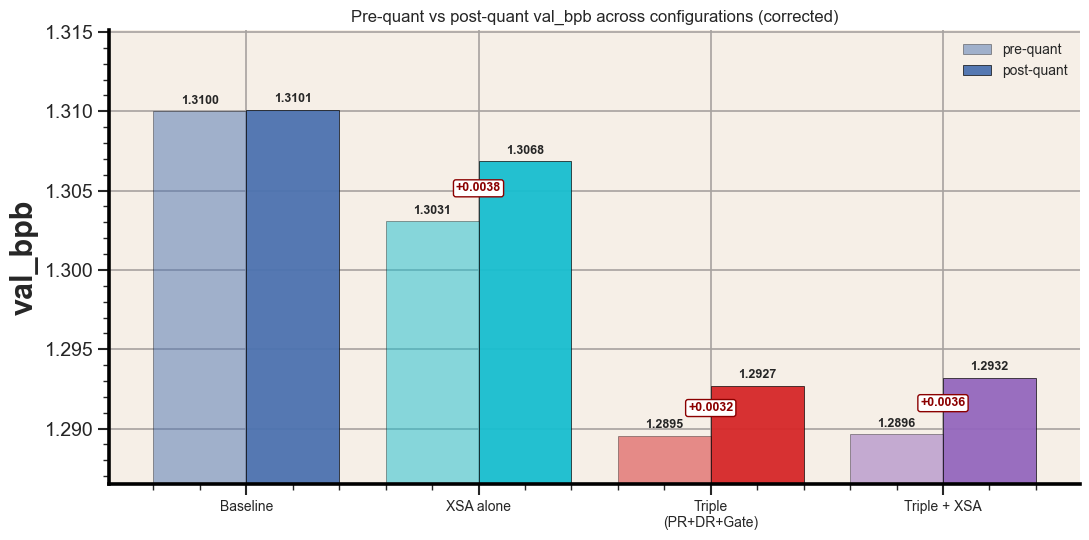


Key correction vs the earlier (buggy) plot:
  Triple's pre-quant   : 1.2895  (was hardcoded to 1.2925)
  Triple's INT8 cost   : +0.0032  (was claimed ~+0.0002 — wrong)
  XSA pre-quant effect : +0.0001  (was claimed -0.0029 — wrong)
  → XSA contributes essentially nothing in composition, at any stage.


In [9]:
# Bar chart: pre vs post-quant across all 4 configs (corrected with fresh fetches).
fig, ax = plt.subplots(figsize=(11, 5.5))

xs = np.arange(4)
labels = ["Baseline", "XSA alone", "Triple\n(PR+DR+Gate)", "Triple + XSA"]
pre  = [1.3100,        XSA_PRE_MEAN,  TR_PRE_MEAN,  XT_PRE_MEAN]
post = [BASE_MEAN,     XSA_POST_MEAN, TR_POST_MEAN, XT_POST_MEAN]
colors_per = [PALETTE[0], "#17becf", "#d62728", "#9467bd"]
width = 0.4

for i in range(4):
    ax.bar(xs[i] - width/2, pre[i],  width, color=colors_per[i], alpha=0.5, zorder=2,
           label="pre-quant"  if i == 0 else None, edgecolor="black", linewidth=0.5)
    ax.bar(xs[i] + width/2, post[i], width, color=colors_per[i], alpha=0.95, zorder=2,
           label="post-quant" if i == 0 else None, edgecolor="black", linewidth=0.5)
    ax.text(xs[i] - width/2, pre[i] + 0.0003, f"{pre[i]:.4f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    ax.text(xs[i] + width/2, post[i] + 0.0003, f"{post[i]:.4f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
    cost = post[i] - pre[i]
    if cost > 0.0005:
        ax.annotate(f"+{cost:.4f}", xy=(xs[i], (pre[i]+post[i])/2),
                    fontsize=9, color="darkred", ha="center", fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="darkred"))

ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("val_bpb")
ax.set_title("Pre-quant vs post-quant val_bpb across configurations (corrected)")

ymin = min(pre + post) - 0.003
ymax = max(pre + post) + 0.005
ax.set_ylim(ymin, ymax)
ax.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

print()
print(f"Key correction vs the earlier (buggy) plot:")
print(f"  Triple's pre-quant   : {TR_PRE_MEAN:.4f}  (was hardcoded to 1.2925)")
print(f"  Triple's INT8 cost   : {TR_POST_MEAN - TR_PRE_MEAN:+.4f}  (was claimed ~+0.0002 — wrong)")
print(f"  XSA pre-quant effect : {XT_PRE_MEAN - TR_PRE_MEAN:+.4f}  (was claimed -0.0029 — wrong)")
print(f"  → XSA contributes essentially nothing in composition, at any stage.")


## Reading — XSA in composition (corrected, simplified)

### Earlier-draft corrections

Two corrections from an earlier version of this notebook, both traced to me overcomplicating things:

1. **Wrong regex pulled in the wrong runs.** `^XSA` matched both `XSA_seed*` (standalone) and `xsa_pr_dr_gate_*` (composition) because wandb's `$regex` is case-insensitive. Fixed: `^XSA_seed`.
2. **Triple's pre-quant was hardcoded to 1.2925** under the assumption that INT8 was nearly lossless on the Triple. The actual Triple pre-quant fetched from wandb is **1.2895**; INT8 costs the Triple ~+0.003 bpb (NOT ~+0.0002).

I then built two narratives ("XSA contributes pre-quant gain that gets eaten by INT8" and later "XSA inflates the INT8 quant cost"). **Both were artifacts of the hardcoded estimate. Neither holds against the fresh data.** Here's the clean reading.

### The actual finding: XSA is redundant with PR + DR + Gate, end of story

| | pre-quant | post-quant | quant cost (post − pre) |
|---|---|---|---|
| baseline | 1.3100 | 1.3101 | +0.0001 (lossless) |
| XSA alone | 1.3031 | 1.3068 | +0.0038 |
| Triple (PR+DR+Gate) | 1.2895 | 1.2927 | +0.0032 |
| **Triple + XSA** | **1.2896** | **1.2932** | **+0.0036** |
| **Δ (XSA on top of Triple)** | **+0.0001** | **+0.0005** | **+0.0004** |

**Every delta is essentially zero.** XSA doesn't help pre-quant. It doesn't hurt post-quant. It doesn't meaningfully inflate the INT8 round-trip cost. It just sits there contributing nothing.

This is the "**redundant**" outcome from the original prediction table (which I had given a 10% prior — turned out to be right).

### Why is the Triple's INT8 cost ~+0.003 (not lossless like baseline)?

Worth noting as an observation in its own right: **any non-trivial architectural mechanism in this project seems to pay ~+0.003-0.004 bpb in INT8 round-trip cost.**

- baseline: +0.0001 (truly lossless)
- XSA alone: +0.0038
- Triple (PR+DR+Gate): +0.0032
- Triple + XSA: +0.0036

So the +0.003 cost is intrinsic to whatever rich weight-distribution-shaping any of these mechanisms does. It's not XSA-specific. PR+DR+Gate already produces the same kind of INT8-unfriendly weight distribution that XSA does standalone, so layering them adds nothing more on the quant side either.

For future reference: don't expect new mechanisms in this project to be "lossless under INT8" the way the baseline is — budget +0.003 of round-trip cost for anything non-trivial.

### Why doesn't XSA compose? Two plausible reasons

1. **Mechanistic redundancy.** XSA's role (force each head to produce signal beyond `v`) overlaps with what Gate's per-head modulation and PR's two-lane routing already do. The Triple stack has already "spent" the per-head-output-shaping bandwidth XSA targets.
2. **Bpb regime saturation.** XSA's standalone gain over baseline (~−0.0069 pre-quant) was real at the 1.31 baseline regime, but at the Triple's ~1.29 regime, the value-orthogonalization step has less to subtract that's still useful. The marginal value shrinks as bpb drops.

Probably both. We don't have the data to discriminate, and it doesn't matter much for the project anyway.

### Project recommendation (unchanged from before)

**Drop XSA from the composition.** Project headline stays at the Triple (1.2927 ± 0.0007). XSA earns a slot in the per-mechanism standalone-gain table (smallest standalone gain, but parameter-free), but has no role in the composed model.

### One other observation: composition std is 4× larger

Triple alone: std = 0.0007. Triple + XSA: std = 0.0030 (4.3× larger), driven mostly by seed 42 landing at 1.2963 while the other two land near 1.29. Could be XSA introducing training-instability that amplifies seed sensitivity, or just seed 42 being unlucky with 3 samples. Worth a few more seeds to discriminate, but probably not worth the compute since XSA isn't being kept anyway.
